First model: TF-IDF with genres. Not great, recommendations based on genre's show a wide spread of results.

                                                title                                       genres  distances
3654   Adventures of Rocky and Bullwinkle, The (2000)  Adventure|Animation|Children|Comedy|Fantasy        0.0
48524                         The Dragon Spell (2016)  Adventure|Animation|Children|Comedy|Fantasy        0.0
12970                  Tale of Despereaux, The (2008)  Adventure|Animation|Children|Comedy|Fantasy        0.0
58508       Dragons: Dawn Of The Dragon Racers (2014)  Adventure|Animation|Children|Comedy|Fantasy        0.0
70015                                     Soul (2020)  Adventure|Animation|Children|Comedy|Fantasy        0.0

Second model: TF-IDF with genres and tags. Definitely better, Toy Story (1995) gives 
                       title                                            genres  distances
3021      Toy Story 2 (1999)       Adventure|Animation|Children|Comedy|Fantasy   0.099129
2264    Bug's Life, A (1998)               Adventure|Animation|Children|Comedy   0.186810
14815     Toy Story 3 (2010)  Adventure|Animation|Children|Comedy|Fantasy|IMAX   0.256845
39883    Finding Dory (2016)                        Adventure|Animation|Comedy   0.270749
4781   Monsters, Inc. (2001)       Adventure|Animation|Children|Comedy|Fantasy   0.281538

## Introduction
The purpose of this assignment is to develop a movie recommendation system. The application takes a movie as input and returns five recommended movies.

The most common approaches in recommendation systems are:
- Content-based filtering  
- Collaborative filtering  

In this model, content-based filtering is used, where recommendations are based on similarities in movie attributes.

## Dataset
The dataset used is from [MovieLens](https://grouplens.org/datasets/movielens/) consists of multiple CSV files, structured as follows:
- Movies.csv – contains genre information  
- Tags.csv – contains descriptive keywords related to each movie  
- Ratings.csv – contains user ratings of movies  
- Tag Genome (genome-scores.csv and genome-tags.csv) - Not used


## Data-analysis

In a content-based model, genres represent one of the primary ways to categorize movies. The dataset contains approximately 20 different genres, which are used for categorical classification.

- Plot 1 – shows the distribution of genres  
- Plot 2 – shows the number of genres per movie, indicating limited variation  
- Plot 3 – shows the number of tags per movie, indicating a wider distribution  

Genres provide a relatively coarse representation of movies. Many films share the same genres despite significant differences in content, tone, and theme. Therefore, tags are combined with genres to reduce variance in the recommendations and improve overall precision.

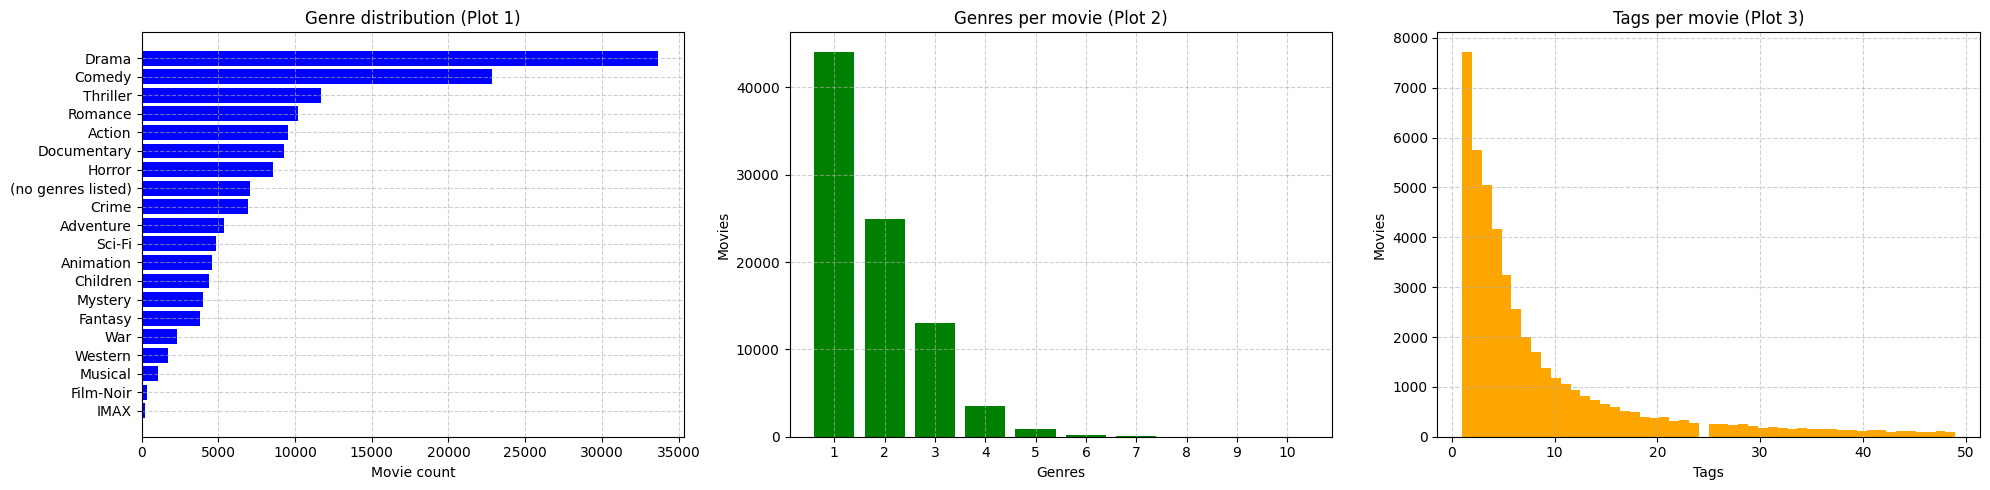

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from recommender import load_data, clean_genres, prepare_tags

movies, ratings, tags = load_data()

genres_exploded = movies["genres"].str.split("|").explode()
genre_counts = genres_exploded.value_counts().sort_values(ascending=True)

genres_per_movie = movies["genres"].str.split("|").apply(len)
genre_per_movie_sorted = genres_per_movie.value_counts().sort_index()

tags_per_movie = tags.groupby("movieId").size()

fig, axes = plt.subplots(1,3, figsize=(20,5))

axes[0].barh(genre_counts.index, genre_counts.values, color="blue")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_title("Genre distribution (Plot 1)")
axes[0].set_xlabel("Movie count")

axes[1].bar(genre_per_movie_sorted.index, genre_per_movie_sorted.values, color="green")
axes[1].set_xticks(range(1, genres_per_movie.max() + 1))
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].set_title("Genres per movie (Plot 2)")
axes[1].set_xlabel("Genres")
axes[1].set_ylabel("Movies")

axes[2].hist(tags_per_movie[tags_per_movie < 50], bins=50, color="orange")
axes[2].grid(True, linestyle="--", alpha=0.6)
axes[2].set_title("Tags per movie (Plot 3)")
axes[2].set_xlabel("Tags")
axes[2].set_ylabel("Movies")

plt.tight_layout()
plt.show()

## Model
To improve the representation of each movie, genre information was split up into individual categories and combined together with tags from user reviews.

In [19]:
movies = clean_genres(movies)
tags_grouped = prepare_tags(tags)
movies = movies.merge(tags_grouped, on="movieId", how="left")

movies["tag"] = movies["tag"].fillna("")

movies["features"] = movies["genres_clean"] + " " + movies["tag"]
movies[["title", "genres", "genres_clean", "tag", "features"]].head(3)

,title,genres,genres_clean,tag,features
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure Animation Children Comedy Fantasy,animation friendship toys animation Disney Pix...,Adventure Animation Children Comedy Fantasy an...
1,Jumanji (1995),Adventure|Children|Fantasy,Adventure Children Fantasy,animals based on a book fantasy magic board ga...,Adventure Children Fantasy animals based on a ...
2,Grumpier Old Men (1995),Comedy|Romance,Comedy Romance,sequel moldy old old age old men wedding old p...,Comedy Romance sequel moldy old old age old me...


The model uses TF-IDF vectorization to vectorize each movie based on the describing features. Similarity between movies was computed using cosine similarity and Nearest Neighbours to give the 5 closest neighbours (movies) as a recommendation.
### Hyperparameters used
* TF-IDF:
    * stop_words="english"
* Nearest Neighbours:
    * metric="cosine"
    * algorithm="brute",
    * n_neighbours= n(5) + 1

## Results
A genre only model was used as a baseline model. However it produced less accurate results due to the broad variance in the genre category.

Result based on: "Toy Story (1995)"

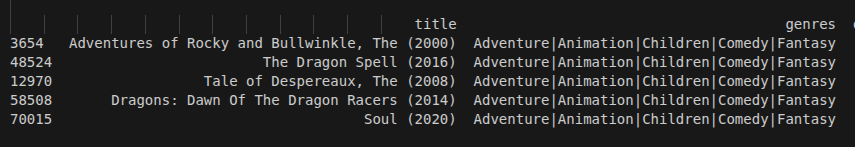

The model uses the same parameters as the baseline model. However, when adding tags to the features the recommendations became more specific and relevant. Ratings were also incorporated as a weighting factor, calculated based on both the average ratings and the number of ratings (inspired by the IMDB formula).

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from recommender import recommend, build_recommender

movies, tfidf_matrix, knn, indices, = build_recommender()
matched_title, recs = recommend(
    "Toy Story",
    movies,
    tfidf_matrix,
    knn,
    indices
)

display(recs)

,title,genres,weighted_rating,distances,similarity,score
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,3.808498,0.099129,0.900871,1.773159
1,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,3.831059,0.256845,0.743155,1.669526
2,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,3.840061,0.281538,0.718462,1.654942
3,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,3.558771,0.186810,0.813190,1.636865
4,Finding Dory (2016),Adventure|Animation|Comedy,3.538839,0.270749,0.729251,1.572128


## Discussion
Several simplifications were made in this project. The model is based solely on a content filtering algorithm using the features in tags and genres to filter out movies with TF-IDF vectorization and cosine similiarities. The weighted score added a dimensionality to the baseline model with more accurate recommendation based also on ratings.

This model has it's limitations. It does not account for individual user preferences since the recommender only shows recommendations based on item-similarity. Tags are also user-generated and can be both inconsistent and sparse which could lead to missleading results. Despite the limitations, a similar model could be used to help find movies based on descriptions. 